## Adaptive Covariance Inflation for an Ensemble Kalman Filter 
[元論文のリンク](https://journals.ametsoc.org/view/journals/mwre/139/5/2010mwr3570.1.xml)

## 各種メソッドの定義

In [ ]:
# 各種メソッドの定義
import numpy as np
import matplotlib.pyplot as plt

## Lorenz96モデルの定義
def L96(x, F):
    """
    x: shape (N,) または (N, M)
    F: スカラーまたは shape (N, 1/ M とブロードキャスト可能)
    """
    x = np.asarray(x)
    roll_p1 = np.roll(x, -1, axis=0)
    roll_m1 = np.roll(x, 1, axis=0)
    roll_m2 = np.roll(x, 2, axis=0)
    return (roll_p1 - roll_m2) * roll_m1 - x + F
## オイラー法の実装
def euler_step(x, F, dt):
    """
    オイラー法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    dxdt = L96(x, F)
    return x + dxdt * dt
## 4次のルンゲクッタ法の実装
def rk4_step(x, F, dt):
    """
    4次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F) * dt
    k2 = L96(x + 0.5 * k1, F) * dt
    k3 = L96(x + 0.5 * k2, F) * dt
    k4 = L96(x + k3, F) * dt
    return x + (k1 + 2 * k2 + 2 * k3 + k4) / 6

## 2次のルンゲクッタ法の実装
def rk2_step(x, F, dt):
    """
    2次のルンゲクッタ法による1ステップの時間積分
    x: 現在の状態変数の配列
    F: 外部からの強制力
    dt: 時間ステップ
    """
    k1 = L96(x, F)
    k2 = L96(x + dt * k1, F)
    return x + (dt / 2) * (k1 + k2)

## 状態変数の配列のコンストラクタ
class StateArray:
    def __init__(self, N, F, dt, method='rk4'):
        """
        状態変数の配列を初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        method: 使用する時間積分メソッド ('euler', 'rk2', 'rk4')
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.method = method
        self.x = F * np.ones(N)  # 初期状態をFで初期化
        self.x[N // 2-1] *= 1.001  # 中央の値を少し変化させる

    def step(self):
        """
        1ステップの時間積分を実行するメソッド
        """
        if self.method == 'euler':
            self.x = euler_step(self.x, self.F, self.dt)
        elif self.method == 'rk2':
            self.x = rk2_step(self.x, self.F, self.dt)
        elif self.method == 'rk4':
            self.x = rk4_step(self.x, self.F, self.dt)
        else:
            raise ValueError("Unknown method: {}".format(self.method))

# 与えらえたNの個数に基づいて、変数j個×N個のガウシアンノイズをリストで返すメソッド
def generate_gaussian_noise(j=40, N=1000, mean=0.0, std=1.0):
    """
    N個のガウシアンノイズを生成する関数
    N: ノイズの個数
    mean: ノイズの平均値
    std: ノイズの標準偏差
    """
    return [np.random.normal(mean, std, j) for _ in range(N)]

def make_homogeneous_H(n, p):
    """
    p x n の均等観測演算子 H を作成する。
    観測は状態ベクトル長 n の要素から均等間隔で p 個を選ぶ（重複しないよう int に丸める）。
    戻り値:
      H : ndarray, shape (p, n)  -- 観測演算子（選んだ要素に対応する行が単位ベクトル）
      indices : ndarray, shape (p,) -- 観測に使う状態インデックス（0-based）
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    # 均等にインデックスを決める（端点を含める）
    indices = np.linspace(0, n - 1, p, dtype=int)
    # インデックスが重複する場合は調整（微小ずらし）
    # （通常は p<=n なら重複は起きにくいが念のため）
    uniq, counts = np.unique(indices, return_counts=True)
    if uniq.size != indices.size:
        # 重複を解消する簡易処理：採用済みインデックスを避けつつ前方に埋める
        used = set()
        new_idx = []
        for v in indices:
            if v in used:
                # 前後を探索して未使用インデックスを探す
                left = v - 1
                right = v + 1
                found = None
                while left >= 0 or right < n:
                    if left >= 0 and left not in used:
                        found = left
                        break
                    if right < n and right not in used:
                        found = right
                        break
                    left -= 1
                    right += 1
                if found is None:
                    raise RuntimeError("Cannot resolve duplicate observation indices")
                new_idx.append(found)
                used.add(found)
            else:
                new_idx.append(int(v))
                used.add(int(v))
        indices = np.array(new_idx, dtype=int)
    H = np.zeros((p, n), dtype=float)
    for i, idx in enumerate(indices):
        H[i, idx] = 1.0
    return H

def make_dense_H(n, p, dense=False, random_scale=0.01, seed=None):
    """
    n: 状態次元
    p: 観測次元
    dense: True にすると、(i,i)=1 に加えて残りの要素を小さい乱数で埋める（"dense" 化）
    random_scale: dense=True のときの乱数標準偏差
    seed: 乱数シード（再現性が欲しいときに指定）
    戻り値:
      H: ndarray, shape (p, n)
    """
    if not (1 <= p <= n):
        raise ValueError("p must satisfy 1 <= p <= n")
    H = np.zeros((p, n), dtype=float)
    # 最初の p 行について対角成分 (i,i) を 1 にする
    for i in range(p):
        H[i, i] = 1.0

    if dense:
        rng = np.random.default_rng(seed)
        # 対角の位置は上書きしないようマスクを作る
        mask = np.ones((p, n), dtype=bool)
        for i in range(p):
            mask[i, i] = False
        H[mask] = rng.normal(loc=0.0, scale=random_scale, size=mask.sum())

    return H

## 固定インフレーションのLETKF

In [ ]:
class EnKF_LETKF:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, obs_error_std=1.0, inflation_factor=1.02, loc_radius=5):
        """
        LETKFを初期化するクラス
        N: 状態変数の数
        F: 外部からの強制力
        dt: 時間ステップ
        H: 観測行列
        R: 観測誤差共分散行列
        ensemble_size: アンサンブルのサイズ
        obs_error_std: 観測誤差の標準偏差

        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N,N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p, self.p) * obs_error_std
        self.Z = None
        self.ensemble_mean = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        self.inflation_factor = inflation_factor
        self.L = self.localization_matrix(loc_radius=loc_radius)
        # Hが密行列(dense)の場合や特殊な配置の場合、obs_indicesの自動判定は注意が必要
        # ここでは「Hの各列がいずれかの観測に関与しているか」で判定している
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]

    def initialize_ensemble(self, x0):
        np.random.seed(42)  # For reproducibility
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed() # シード値の固定を解除

    def localization_matrix(self, loc_radius):
        """Gaussian Functionでの局所化行列を作成する"""
        ### グリッド間距離の計算
        L = np.zeros((self.N, self.N))
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2*np.sqrt(10/3)*loc_radius:
                    # exp(- (dist / loc_radius)^2 / 2)  の形でガウシアン関数を適用
                    L[i, j] = np.exp(-0.5 * (dist / loc_radius) ** 2)
                else:
                    L[i, j] = 0.0
        return L
                    
    def forecast(self):
        """アンサンブルの予測ステップを実行する"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = self.step_model(self.ensemble[:, i])
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        self.Z = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
    def step_model(self, x):
        """モデルの1ステップ予測を実行する"""
        return rk4_step(x, self.F, self.dt)

    def analysis(self, observation):
        """アンサンブルの解析ステップを実行する"""
        # (1) Preparation Step
        # Zb = self.Z * np.sqrt(self.inflation_factor)
        Zb = self.Z * self.inflation_factor
        Yb = self.H @ Zb
        diff = self.H @ observation.reshape(-1, 1) - self.H @ self.ensemble_mean
        # (2) Local Analysis Step
        L = self.L # 局所化行列の取得
        Xa = np.zeros_like(self.ensemble)
        # Rの逆行列を事前に計算
        R_inv = np.linalg.inv(self.R)
        
        # エラーチェック用のフラグ
        has_error = False
        
        for i in range(self.N):
            # (2.1) Eigenvalue Decomposition with Localization
            # 局所化行列の取得
            loc_weights = L[i, :]
            loc_weights_obs = loc_weights[self.obs_indices]          # 長さ = 観測次元
            R_loc_inv = R_inv * loc_weights_obs[:, None]
            Pa_tilde_inv = np.eye(self.ensemble_size) + Yb.T @ R_loc_inv @ Yb
            
            try:
                D, C = np.linalg.eigh(Pa_tilde_inv)
            except np.linalg.LinAlgError:
                if not has_error: # 最初のエラーだけ詳細を表示
                    print(f"LinAlgError at grid point {i}")
                    print(f"Pa_tilde_inv max: {np.max(Pa_tilde_inv)}, min: {np.min(Pa_tilde_inv)}")
                    print(f"Contains NaNs: {np.isnan(Pa_tilde_inv).any()}")
                    print(f"Contains Infs: {np.isinf(Pa_tilde_inv).any()}")
                    has_error = True
                # エラー時は更新せず予測値をそのまま使う（あるいは例外を投げる）
                # ここでは例外を再送出する
                raise

            D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
            Pa_tilde = C @ np.diag(1.0 / D) @ C.T
            pa_tilde_sqrt = C @ D_inv_sqrt @ C.T
            # (2.2) Update Ensemble
            T = Pa_tilde @ Yb.T @ R_loc_inv @ diff + np.sqrt(self.ensemble_size - 1)* pa_tilde_sqrt
            Xa[i, :] = self.ensemble_mean[i, 0] + Zb[i, :] @ T
        # (3) Collect analysis Ensemble of all model grid points
        self.ensemble = Xa
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        Za = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        
        self.P_analysis_list.append((Za @ Za.T).copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)

    def get_ensemble_list(self):
        return self.ensemble_list

    def get_P_analysis_list(self):
        return self.P_analysis_list  

    def calculate_rmse(self, true_states):
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse**2, axis=1))

    def calculate_spread(self):
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list

## Adaptive Covariance Inflation対応のLETKFの実装

In [ ]:
import numpy as np
class EnKF_LETKF_Adaptive:
    def __init__(self, N, F, dt, H=None, R=None, ensemble_size=20, 
                 obs_error_std=1.0, 
                 initial_inflation=1.0,  # 初期インフレーション値
                 prior_inflation_var=0.04**2, # Miyoshi2011推奨の事前分散 (v^b)
                 loc_radius=3):
        """
        Miyoshi (2011) の適応的インフレーション対応 LETKF
        """
        self.N = N
        self.F = F
        self.dt = dt
        self.H = H if H is not None else np.eye(N,N)
        self.p = self.H.shape[0]
        self.R = R if R is not None else np.eye(self.p, self.p) * obs_error_std
        self.Z = None
        self.ensemble_mean = None
        self.ensemble_list = []
        self.P_analysis_list = []
        self.inflation_parameter_list = []
        self.ensemble_size = ensemble_size
        self.obs_error_std = obs_error_std
        self.ensemble = None
        
        # --- Adaptive Inflation 用の変数を初期化 ---
        # インフレーション値はグリッドごとに異なる値を持つ (ベクトル)
        self.inflation_parameter = np.ones(self.N) * initial_inflation
        # インフレーションの事前分散 (固定パラメータとして扱うのが一般的)
        self.prior_inflation_var = prior_inflation_var 
        
        self.L = self.localization_matrix(loc_radius=loc_radius)
        self.obs_indices = np.where(np.any(self.H, axis=0))[0]

    def initialize_ensemble(self, x0):
        np.random.seed(42)
        members = [x0 + np.random.normal(0, 1, self.N) for _ in range(self.ensemble_size)]
        self.ensemble = np.column_stack(members)
        np.random.seed()

    def localization_matrix(self, loc_radius):
        """Gaussian Functionでの局所化行列を作成する"""
        L = np.zeros((self.N, self.N))
        # 注: 実装効率化のため、ここでは単純な距離計算にしています
        for i in range(self.N):
            for j in range(self.N):
                dist = min(abs(i - j), self.N - abs(i - j))
                if dist < 2*np.sqrt(10/3)*loc_radius:
                    L[i, j] = np.exp(-0.5 * (dist / loc_radius) ** 2)
                else:
                    L[i, j] = 0.0
        return L
                    
    def forecast(self):
        """アンサンブルの予測ステップ"""
        for i in range(self.ensemble_size):
            self.ensemble[:, i] = self.step_model(self.ensemble[:, i])
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        # 摂動の計算 (正規化込み)
        self.Z = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)

    def step_model(self, x):
        """モデルの1ステップ予測 (RK4などを想定)"""
        # ユーザー提供コードに rk4_step が含まれていなかったため、ダミー実装または外部関数と想定
        # ここでは外部関数 rk4_step がある前提で記述します
        return rk4_step(x, self.F, self.dt)

    def analysis(self, observation):
        """
        適応的インフレーションを含む解析ステップ
        Miyoshi (2011) の Eq.6, Eq.14, Eq.15 を実装
        """
        # (1) Preparation Step
        # 空間的に異なるインフレーション値を適用 (Broadcasting)
        # self.Z: (N, m), self.inflation_parameter: (N,) -> (N, 1)
        Zb = self.Z * self.inflation_parameter[:, np.newaxis]
        
        Yb = self.H @ Zb
        # Innovation vector d = y - Hx_b
        diff = self.H @ observation.reshape(-1, 1) - self.H @ self.ensemble_mean
        
        # (2) Local Analysis Step
        L = self.L
        Xa = np.zeros_like(self.ensemble)
        R_inv = np.linalg.inv(self.R)
        
        # 次のステップのために更新されたインフレーション値を格納する配列
        new_inflation_parameter = self.inflation_parameter.copy()
        self.inflation_parameter_list.append(new_inflation_parameter)

        has_error = False
        
        for i in range(self.N):
            # --- 局所化重みの取得 ---
            loc_weights = L[i, :]
            loc_weights_obs = loc_weights[self.obs_indices]
            
            # 局所化された Rの逆行列: R_loc_inv = R^-1 * rho
            # 対角行列を仮定した高速化 (一般的な実装)
            R_loc_inv = R_inv * loc_weights_obs[:, None] 

            # --- Adaptive Inflation Estimation (Miyoshi 2011) ---
            # 有効観測点数 p_eff = tr(rho)
            p_eff = np.sum(loc_weights_obs)

            if p_eff > 1e-4: # 観測の影響がある場合のみ計算
                # Eq.14: 分子の計算 (Innovation statistics)
                # tr(d d^T rho R^-1) = d^T (rho R^-1) d
                # diff は (p, 1) なので結果はスカラー
                numerator_term = (diff.T @ R_loc_inv @ diff)[0, 0]
                alpha_o_numerator = numerator_term - p_eff

                # Eq.14: 分母の計算 (Forecast spread statistics)
                # tr(H P H^T rho R^-1) = tr(Y_b Y_b^T R_loc_inv) = tr(Y_b^T R_loc_inv Y_b)
                # Yb: (p, m), R_loc_inv: (p, p)
                # P = Z Z^T なので、ここでは Yb Yb^T が HPH^T に相当
                denom_matrix = Yb.T @ R_loc_inv @ Yb
                denominator = np.trace(denom_matrix)

                if denominator > 1e-10:
                    # 観測から推定されたインフレーション値 alpha_o (Eq.14)
                    alpha_o = alpha_o_numerator / denominator
                    
                    # # 異常値の回避 (例えば負の値や極端な値を制限)
                    # # 論文では言及が少ないが、実装上は下限1.0などを設けることが多い
                    # alpha_o = max(1.0, alpha_o)

                    # 推定分散 v_o (Eq.15)
                    # 論文の改良: alpha_true の代わりに alpha_b (prior) を使用
                    alpha_b = self.inflation_parameter[i]
                    
                    # v_o = (2 / p_eff) * ((alpha * denom + p_eff) / denom)^2
                    term_inside = (alpha_b * denominator + p_eff) / denominator
                    v_o = (2.0 / p_eff) * (term_inside ** 2)

                    # Kalman Filter Update for Inflation (Eq.6)
                    v_b = self.prior_inflation_var
                    
                    # K = v_b / (v_b + v_o)
                    weight = v_b / (v_b + v_o)
                    
                    # alpha_a = (1-K)alpha_b + K*alpha_o
                    # 数式変形: alpha_a = alpha_b + K * (alpha_o - alpha_b)
                    new_alpha = alpha_b + weight * (alpha_o - alpha_b)
                    
                    # # 極端なインフレーションを防ぐリミッター (任意だが推奨)
                    # new_alpha = np.clip(new_alpha, 1.0, 1.5) # 例: 最大50%増まで
                    
                    new_inflation_parameter[i] = new_alpha

            # --- Standard LETKF Analysis ---
            # Pa_tilde_inv = (m-1)I + Yb^T R_loc_inv Yb
            # 注: self.Z は sqrt(m-1) で割られているため、
            # 通常のLETKFの式 (m-1)I / rho + ... ではなく、
            # I + Yb^T R_loc_inv Yb となる (Yb自体が正規化されているため)
            Pa_tilde_inv = np.eye(self.ensemble_size) + Yb.T @ R_loc_inv @ Yb
            
            try:
                D, C = np.linalg.eigh(Pa_tilde_inv)
                D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
                D_inv = np.diag(1.0 / D)
                
                # Pa_tilde = C D^-1 C^T
                Pa_tilde = C @ D_inv @ C.T
                # pa_tilde_sqrt = C D^-0.5 C^T
                pa_tilde_sqrt = C @ D_inv_sqrt @ C.T
                
                # Update weights T
                # T = Pa_tilde Yb^T R_loc_inv d + sqrt(m-1) * Pa_tilde_sqrt
                w_mean = Pa_tilde @ Yb.T @ R_loc_inv @ diff
                W_pert = np.sqrt(self.ensemble_size - 1) * pa_tilde_sqrt
                
                T = w_mean + W_pert
                
                # Update Analysis Ensemble
                # Xa = x_bar + Zb * T
                Xa[i, :] = self.ensemble_mean[i, 0] + Zb[i, :] @ T

            except np.linalg.LinAlgError:
                if not has_error:
                    print(f"LinAlgError at grid point {i}")
                    has_error = True
                # エラー時は更新せず、予測値（事前分布）をそのまま採用
                Xa[i, :] = self.ensemble[i, :]

        # (3) Update State and Inflation
        self.ensemble = Xa
        self.inflation_parameter = new_inflation_parameter # 次のステップのためにインフレーション値を更新
        
        self.ensemble_mean = np.mean(self.ensemble, axis=1, keepdims=True)
        # 解析誤差共分散の保存などは必要に応じて記述
        Za = (self.ensemble - self.ensemble_mean) / np.sqrt(self.ensemble_size - 1)
        self.P_analysis_list.append((Za @ Za.T).copy().T)
        self.ensemble_list.append(self.ensemble.copy().T)
    
    def get_P_analysis_list(self):
        return self.P_analysis_list
    
    def get_ensemble_list(self):
        return self.ensemble_list
    
    def get_inflation_parameter_list(self):
        return self.inflation_parameter_list

    def calculate_rmse(self, true_states):
        ensemble_mean = np.mean(self.ensemble_list, axis=1)
        rmse = ensemble_mean - true_states
        return np.sqrt(np.mean(rmse**2, axis=1))

    def calculate_spread(self):
        spread_list = []
        for P_analysis in self.P_analysis_list:
            spread = np.sqrt(np.trace(P_analysis) / self.N)
            spread_list.append(spread)
        return spread_list

## 完全モデル実験

Data generation completed.


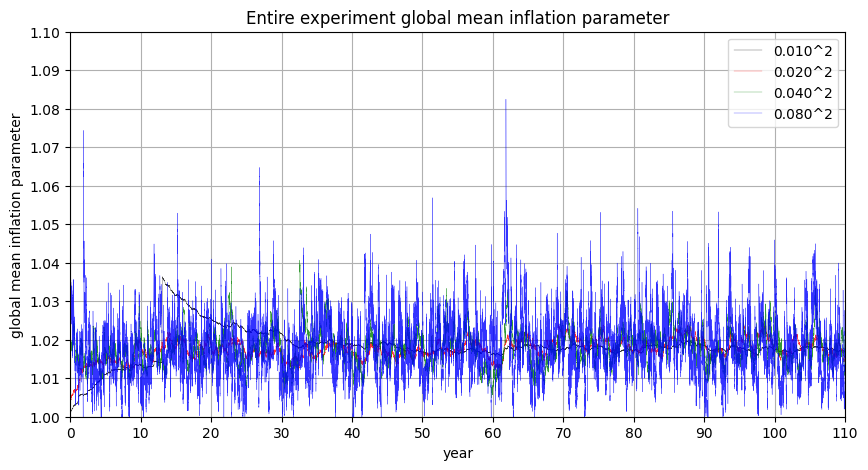

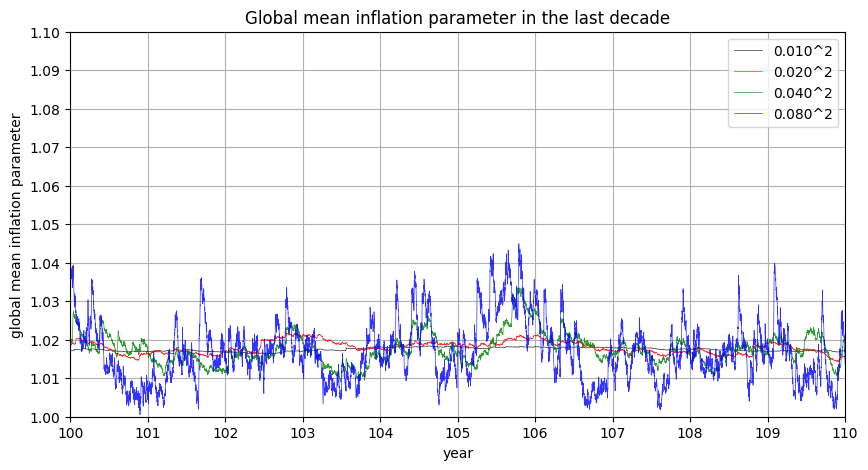

0.010^2 Land Inflation Mean (post spin-up): 2.7957%
0.010^2 Ocean Inflation Mean (post spin-up): 1.0177%
0.020^2 Land Inflation Mean (post spin-up): 2.4588%
0.020^2 Ocean Inflation Mean (post spin-up): 1.1302%
0.040^2 Land Inflation Mean (post spin-up): 2.3334%
0.040^2 Ocean Inflation Mean (post spin-up): 1.2756%
0.080^2 Land Inflation Mean (post spin-up): 2.2016%
0.080^2 Ocean Inflation Mean (post spin-up): 1.4446%


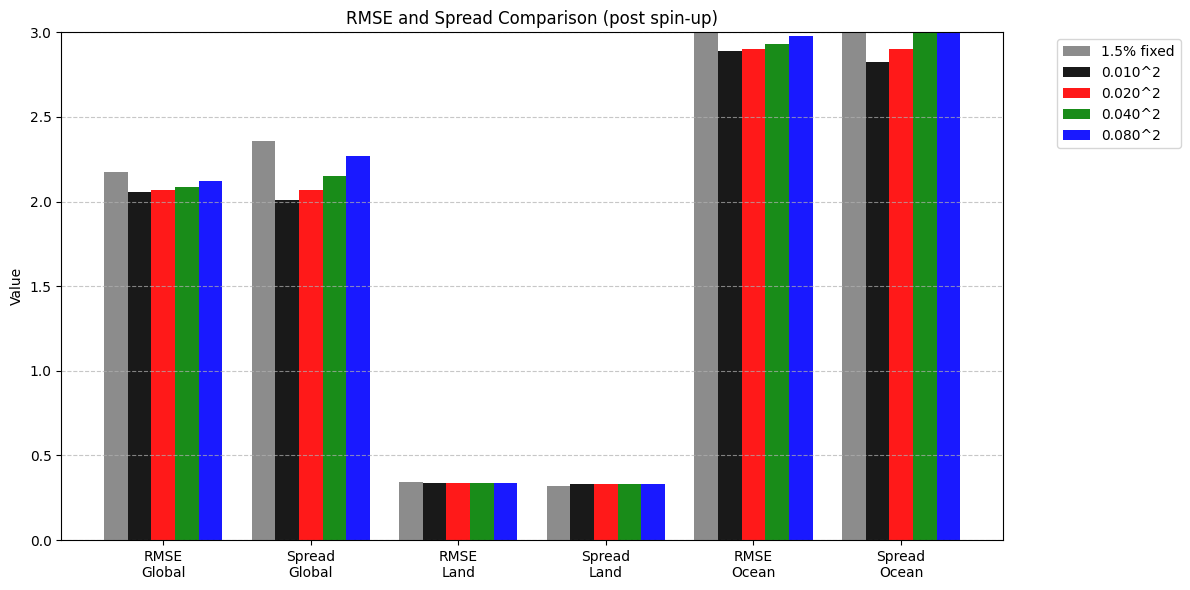

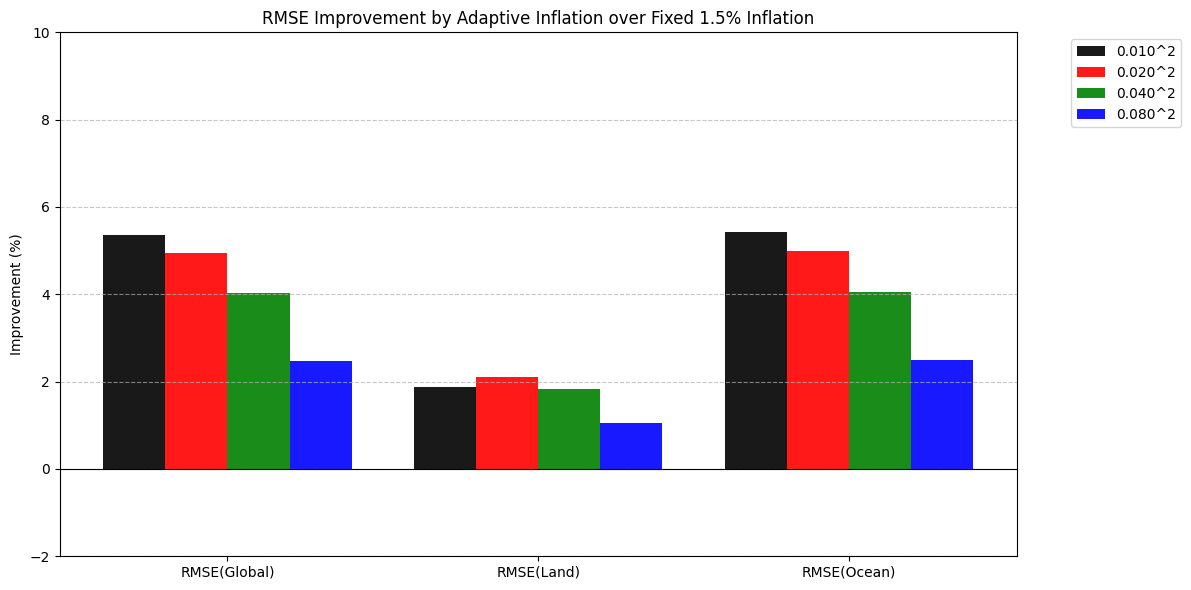

In [9]:
# ...existing code...
# パラメータ設定
N = 40          # 状態変数の次元
F = 8.0         # 外部からの強制力
dt = 0.05       # 時間ステップ
dt_per_day = 0.2
total_year = 110      # 総実験年数
spinup_year = 10    # スピンアップ期間
total_cycles = int(total_year * 365 * (dt_per_day / dt))
spinup_cycles = int(spinup_year * 365 * (dt_per_day / dt))
ens_member_size = 10  # アンサンブルメンバー数
loc_radius = 3     # 局所化半径
prior_inflation_var_list = [0.01**2, 0.02**2, 0.04**2, 0.08**2]
reference_prior_inflation_var = 0.04**2  # 棒グラフなど詳細解析に使うリファレンス値
dense_H = make_dense_H(N, N//2, dense=False)


assert reference_prior_inflation_var in prior_inflation_var_list, "Reference prior inflation variance must be included in the list."

# 真値の生成
true_state = StateArray(N, F, dt, method='rk4')
true_states = []
for cycle in range(total_cycles):
    true_state.step()
    true_states.append(true_state.x.copy())
true_states = np.array(true_states)  # shape (total_cycles, N)

# 真値に観測ノイズを加えた観測データの生成
obs_error_std = 1.0
observations = true_states + np.random.normal(0, obs_error_std, true_states.shape)

print("Data generation completed.")

# 通常のLETKFの初期化(比較用、1.5%固定インフレーション)
enkf_letkf = EnKF_LETKF(N, F, dt, dense_H, ensemble_size=ens_member_size, obs_error_std=obs_error_std, inflation_factor=1.015, loc_radius=loc_radius)

# LETKF with Adaptive Covariance Inflationの初期化 (prior varianceごとに実行)
adaptive_filters = {}
for prior_var in prior_inflation_var_list:
    adaptive_filters[prior_var] = EnKF_LETKF_Adaptive(N, F, dt, dense_H, ensemble_size=ens_member_size, obs_error_std=obs_error_std, loc_radius=loc_radius, prior_inflation_var=prior_var)

# アンサンブルの初期化
initial_state = true_states[0] + np.random.normal(0, 1.0, N)
enkf_letkf.initialize_ensemble(initial_state)
for filt in adaptive_filters.values():
    filt.initialize_ensemble(initial_state)

# データ同化ループ
for cycle in range(total_cycles):
    # 通常のLETKF
    enkf_letkf.forecast()
    enkf_letkf.analysis(observations[cycle])
    # LETKF with Adaptive Covariance Inflation (prior varianceごと)
    for filt in adaptive_filters.values():
        filt.forecast()
        filt.analysis(observations[cycle])

# 結果の評価
adaptive_results = {}
for prior_var, filt in adaptive_filters.items():
    inflation_params = np.array(filt.get_inflation_parameter_list())  # shape (total_cycles, N)
    adaptive_results[prior_var] = {
        "inflation_params": inflation_params,
        "inflation_params_mean": np.mean(inflation_params, axis=1),
        "rmse": filt.calculate_rmse(true_states),
        "spread": filt.calculate_spread(),
    }

years = np.arange(total_cycles) * (dt / dt_per_day) / 365
tick_step = 10

## 全期間のInflation値の全地点平均をプロット
color = ['black', 'red', 'green', 'blue']
plt.figure(figsize=(10, 5))
for prior_var, metrics in adaptive_results.items():
    label = f"{np.sqrt(prior_var):.3f}^2"
    plt.plot(years, metrics["inflation_params_mean"], label=label, color=color.pop(0), lw=0.25, alpha=0.8)
plt.xlim(0, total_year)
plt.xticks(np.arange(0, total_year + 1, tick_step))
plt.ylim(1.0, 1.1)
plt.yticks(np.arange(1.0, 1.1, 0.01))
plt.grid()
plt.xlabel('year')
plt.ylabel('global mean inflation parameter')
plt.title('Entire experiment global mean inflation parameter')
plt.legend()
plt.show()

## 直近10年間 (もしくは利用可能な最終期間) のInflation値平均を拡大表示
color = ['black', 'red', 'green', 'blue']
plt.figure(figsize=(10, 5))
window_years = min(10, total_year)
window_start = max(total_year - window_years, 0)
window_tick_step = 1
window_ticks = np.arange(window_start, total_year + 1, window_tick_step)
if window_ticks.size == 0:
    window_ticks = np.array([window_start, total_year])
for prior_var, metrics in adaptive_results.items():
    label = f"{np.sqrt(prior_var):.3f}^2"
    plt.plot(years, metrics["inflation_params_mean"], label=label, color=color.pop(0), lw=0.5, alpha=0.8)
plt.xlim(window_start, total_year)
plt.xticks(window_ticks)
plt.ylim(1.0, 1.1)
plt.yticks(np.arange(1.0, 1.1, 0.01))
plt.grid()
plt.xlabel('year')
plt.ylabel('global mean inflation parameter')
plt.title('Global mean inflation parameter in the last decade')
plt.legend()
plt.show()

## スピンアップ期間を除いたInflation平均 (Land/Ocean) をprior varianceごとに表示
for prior_var, metrics in adaptive_results.items():
    inflation_params = metrics["inflation_params"]
    inflation_params_land = (np.mean(inflation_params[spinup_cycles:, 0:20]) - 1) * 100
    inflation_params_ocean = (np.mean(inflation_params[spinup_cycles:, 20:40]) - 1) * 100
    label = f"{np.sqrt(prior_var):.3f}^2"
    print(f"{label} Land Inflation Mean (post spin-up): {inflation_params_land:.4f}%")
    print(f"{label} Ocean Inflation Mean (post spin-up): {inflation_params_ocean:.4f}%")


## --------------------------------------------------------------------------------
## 比較データの準備 (Fixed LETKF)
## --------------------------------------------------------------------------------
# スピンアップ期間を除いた100年分のRMSEとSpreadをGlobal/Land/Oceanで評価
ensemble_list = np.array(enkf_letkf.get_ensemble_list())  # shape (total_cycles, ens_member_size, N)
P_analysis_list = np.array(enkf_letkf.get_P_analysis_list())  # shape (total_cycles, N, N)
rmse = enkf_letkf.calculate_rmse(true_states)
spread = enkf_letkf.calculate_spread()

# Fixed results
rmse_global_fixed = np.mean(rmse[spinup_cycles:])
spread_global_fixed = np.mean(spread[spinup_cycles:])
rmse_land_fixed = np.mean(np.sqrt(np.mean((np.mean(ensemble_list[spinup_cycles:, :, 0:20], axis=1) - true_states[spinup_cycles:, 0:20])**2, axis=1)))
rmse_ocean_fixed = np.mean(np.sqrt(np.mean((np.mean(ensemble_list[spinup_cycles:, :, 20:40], axis=1) - true_states[spinup_cycles:, 20:40])**2, axis=1)))
spread_land_fixed = np.mean([np.sqrt(np.trace(P_analysis[0:20, 0:20]) / 20) for P_analysis in P_analysis_list[spinup_cycles:]])
spread_ocean_fixed = np.mean([np.sqrt(np.trace(P_analysis[20:40, 20:40]) / 20) for P_analysis in P_analysis_list[spinup_cycles:]])

fixed_results = [rmse_global_fixed, spread_global_fixed, rmse_land_fixed, spread_land_fixed, rmse_ocean_fixed, spread_ocean_fixed]

## --------------------------------------------------------------------------------
## 比較データの準備 (Adaptive LETKF 全パターン)
## --------------------------------------------------------------------------------
all_adaptive_metrics = {}

for prior_var, filt in adaptive_filters.items():
    ens_list = np.array(filt.get_ensemble_list())  # shape (total_cycles, ens_member_size, N)
    P_list = np.array(filt.get_P_analysis_list())  # shape (total_cycles, N, N)
    
    # RMSE / Spread raw series
    r_series = adaptive_results[prior_var]["rmse"]
    s_series = adaptive_results[prior_var]["spread"]

    # Global Mean
    r_g = np.mean(r_series[spinup_cycles:])
    s_g = np.mean(s_series[spinup_cycles:])

    # Land Mean
    mean_ens_land = np.mean(ens_list[spinup_cycles:, :, 0:20], axis=1)
    true_land = true_states[spinup_cycles:, 0:20]
    r_l = np.mean(np.sqrt(np.mean((mean_ens_land - true_land)**2, axis=1)))
    s_l = np.mean([np.sqrt(np.trace(P[0:20, 0:20]) / 20) for P in P_list[spinup_cycles:]])

    # Ocean Mean
    mean_ens_ocean = np.mean(ens_list[spinup_cycles:, :, 20:40], axis=1)
    true_ocean = true_states[spinup_cycles:, 20:40]
    r_o = np.mean(np.sqrt(np.mean((mean_ens_ocean - true_ocean)**2, axis=1)))
    s_o = np.mean([np.sqrt(np.trace(P[20:40, 20:40]) / 20) for P in P_list[spinup_cycles:]])
    
    all_adaptive_metrics[prior_var] = [r_g, s_g, r_l, s_l, r_o, s_o]


## --------------------------------------------------------------------------------
## グラフ描画1: RMSEとSpreadの絶対値比較
## --------------------------------------------------------------------------------
labels = ['RMSE\nGlobal', 'Spread\nGlobal', 'RMSE\nLand', 'Spread\nLand', 'RMSE\nOcean', 'Spread\nOcean']
x = np.arange(len(labels))
color = ['black', 'red', 'green', 'blue']
# バーの設定：1.5%固定 + Prior種類の数
num_bars = 1 + len(prior_inflation_var_list)
total_width = 0.8  # グループ全体の幅
single_width = total_width / num_bars

plt.figure(figsize=(12, 6))

# Fixed Baseline
# オフセット位置の計算: 中心から見て左端へ
start_offset = -total_width / 2 + single_width / 2
plt.bar(x + start_offset, fixed_results, single_width, label='1.5% fixed', alpha=0.9, color='gray')

# Adaptive Results (Loop)
sorted_priors = sorted(prior_inflation_var_list)
for i, pv in enumerate(sorted_priors):
    offset = start_offset + (i + 1) * single_width
    label_str = f"{np.sqrt(pv):.3f}^2"
    plt.bar(x + offset, all_adaptive_metrics[pv], single_width, label=label_str, alpha=0.9, color=color.pop(0))

plt.xticks(x, labels)
plt.ylabel('Value')
plt.title('RMSE and Spread Comparison (post spin-up)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 3) # 必要に応じて調整
plt.yticks(np.arange(0, 3.1, 0.5))
plt.tight_layout()
plt.show()

## --------------------------------------------------------------------------------
## グラフ描画2: 1.5%固定インフレーションとのRMSE改善率 (Global/Land/Ocean)
## --------------------------------------------------------------------------------
# 指標のラベル (RMSEのみ)
imp_labels = ['RMSE(Global)', 'RMSE(Land)', 'RMSE(Ocean)']
x_imp = np.arange(len(imp_labels))
color = ['black', 'red', 'green', 'blue']

plt.figure(figsize=(12, 6))

# RMSEのインデックスは 0, 2, 4
rmse_indices = [0, 2, 4]

# FixedのRMSE値
rmse_fixed_vals = [fixed_results[idx] for idx in rmse_indices]

# バーの設定：Prior種類の数だけ（Fixedは基準なのでプロットしない、あるいは0として扱う）
num_bars_imp = len(prior_inflation_var_list)
total_width_imp = 0.8
single_width_imp = total_width_imp / num_bars_imp

# オフセット位置の初期化
start_offset_imp = -total_width_imp / 2 + single_width_imp / 2

for i, pv in enumerate(sorted_priors):
    # 各Adaptive設定のRMSEを取得
    metrics = all_adaptive_metrics[pv]
    rmse_adaptive_vals = [metrics[idx] for idx in rmse_indices]
    
    # 改善率の計算: (Fixed - Adaptive) / Fixed * 100
    improvements = []
    for f_val, a_val in zip(rmse_fixed_vals, rmse_adaptive_vals):
        imp_pct = (f_val - a_val) / f_val * 100
        improvements.append(imp_pct)
    
    offset = start_offset_imp + i * single_width_imp
    label_str = f"{np.sqrt(pv):.3f}^2"
    plt.bar(x_imp + offset, improvements, single_width_imp, label=label_str, alpha=0.9, color=color.pop(0))

plt.xticks(x_imp, imp_labels)
plt.ylabel('Improvement (%)')
plt.title('RMSE Improvement by Adaptive Inflation over Fixed 1.5% Inflation')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(-2, 10) # 必要に応じて調整
plt.yticks(np.arange(-2, 11, 2))
plt.tight_layout()
plt.show()